# Tennis Doubles Homophily — Main Analysis

Data: Grand Slam doubles matches 2018–2025 (excl. 2020 COVID year). N = 2,192 matches.

Sections:
1. Variable construction
2. Pressure outcomes (tiebreaks, comebacks)
3. Olympic cycle descriptive evidence
4. Baseline regressions — match win / tiebreak win / comeback win
5. Olympic interaction regressions

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from getpass import getuser


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

user = getuser()
df = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx')
print(f'Loaded {df.shape[0]:,} matches | years: {sorted(df["year"].unique())}')

Loaded 2,192 matches | years: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 1. Variable Construction

In [4]:
# ── Tiebreak flags ─────────────────────────────────────────────────────────────
# Regular 7-point tiebreak: set reaches 7-6
df['tb_s1'] = ((df['winners_set1']==7)&(df['losers_set1']==6)) | ((df['winners_set1']==6)&(df['losers_set1']==7))
df['tb_s2'] = ((df['winners_set2']==7)&(df['losers_set2']==6)) | ((df['winners_set2']==6)&(df['losers_set2']==7))
df['regular_tb']    = df['tb_s1'] | df['tb_s2']
df['tb_s3_regular'] = (((df['winners_set3']==7)&(df['losers_set3']==6)) | ((df['winners_set3']==6)&(df['losers_set3']==7))).fillna(False)

# Match tiebreak / super-tiebreak (10-point, set3 ≥ 8): Olympics and Wimbledon post-2018
df['match_tb'] = (df['winners_set3'] >= 8).fillna(False)
df['any_tb']   = df['regular_tb'] | df['match_tb'] | df['tb_s3_regular']

# Who won each tiebreak (winner-team perspective)
df['w_won_tb_s1'] = df['tb_s1'] & (df['winners_set1'] == 7)
df['w_won_tb_s2'] = df['tb_s2'] & (df['winners_set2'] == 7)

# ── Match structure ────────────────────────────────────────────────────────────
df['three_sets']     = df['winners_set3'].notna()
df['winner_lost_s1'] = df['winners_set1'] < df['losers_set1']
df['comeback']       = df['winner_lost_s1'] & df['three_sets']   # winner came back from 0-1 down

# ── Olympic period flags ───────────────────────────────────────────────────────
cycle_map = {
    2018: 'Pre-Tokyo (2018-19)', 2019: 'Pre-Tokyo (2018-19)',
    2021: 'Post-Tokyo (2021)',
    2022: 'Pre-Paris (2022-23)', 2023: 'Pre-Paris (2022-23)',
    2024: 'Paris 2024',
    2025: 'Post-Paris (2025)',
}
df['cycle']         = df['year'].map(cycle_map)
df['pre_olympic']   = df['year'].isin([2022, 2023]).astype(int)   # 2-year build-up to Paris
df['olympic_period']= df['year'].isin([2022, 2023, 2024]).astype(int)
df['olympics_tourn']= (df['tournament'] == 'Olympics').astype(int)

# ── Match-level homophily differences (winner − loser) ────────────────────────
df['same_country_diff']  = df['same_country_winners'].astype(float)  - df['same_country_losers'].astype(float)
df['same_language_diff'] = df['winners_same_language'].astype(float) - df['losers_same_language'].astype(float)
df['ling_prox_diff']     = df['winners_linguistic_proximity'].astype(float) - df['losers_linguistic_proximity'].astype(float)

# Match-level averages (across both teams)
df['same_country_avg']   = (df['same_country_winners'] + df['same_country_losers']) / 2
df['same_language_avg']  = (df['winners_same_language'] + df['losers_same_language']) / 2
df['ling_prox_avg']      = (df['winners_linguistic_proximity'] + df['losers_linguistic_proximity']) / 2

print('Variable construction complete.')

Variable construction complete.


## 2. Pressure Outcomes — Counts and Inspection

In [5]:
print('=== Table 1. Pressure Outcome Counts (all matches, N=2,192) ===')
rows = [
    ('Set-1 tiebreak (7-pt)',                          df['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                          df['tb_s2']),
    ('Set-3 regular tiebreak (7-pt)',                  df['tb_s3_regular']),
    ('Match tiebreak / super-tb (10-pt, set3 ≥ 8)',   df['match_tb']),
    ('Any regular tiebreak (sets 1 or 2)',             df['regular_tb']),
    ('Any tiebreak (all types)',                       df['any_tb']),
    ('Match went to 3 sets',                           df['three_sets']),
    ('Comeback wins (winner lost set 1)',               df['comeback']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

print()
print('Regular tiebreaks by tournament:')
print(df.groupby('tournament')['regular_tb'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

print()
print('Match tiebreaks (super-tb) by tournament/year:')
print(df[df['match_tb']].groupby(['tournament','year']).size().to_frame('N').to_string())

print()
print('Comeback wins by tournament:')
print(df.groupby('tournament')['comeback'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

=== Table 1. Pressure Outcome Counts (all matches, N=2,192) ===
  Set-1 tiebreak (7-pt)                               N= 530  (24.2%)
  Set-2 tiebreak (7-pt)                               N= 569  (26.0%)
  Set-3 regular tiebreak (7-pt)                       N= 230  (10.5%)
  Match tiebreak / super-tb (10-pt, set3 ≥ 8)         N=  30  (1.4%)
  Any regular tiebreak (sets 1 or 2)                  N= 964  (44.0%)
  Any tiebreak (all types)                            N=1076  (49.1%)
  Match went to 3 sets                                N= 903  (41.2%)
  Comeback wins (winner lost set 1)                   N= 395  (18.0%)

Regular tiebreaks by tournament:
                   N   Rate
tournament                 
Australian Open  262 0.4520
Olympics          28 0.4380
Roland Garros    201 0.3460
US Open          165 0.4400
Wimbledon        308 0.5200

Match tiebreaks (super-tb) by tournament/year:
                  N
tournament year    
Olympics   2021   9
           2024  11
Wimbledon  2018   3

### 2.1 Tiebreak types treated together vs separately

Regular tiebreaks (7-point, in sets 1-2) and match tiebreaks (10-point super-tiebreak, set 3) measure the same underlying construct — pressure in a closely contested set — but with different point thresholds. For regression purposes we treat them together as `any_tb`. Match tiebreaks are few (N=30) and concentrated in the Olympics and Wimbledon.

## 3. Olympic Cycle Descriptive Evidence

> **Note on 2024-25 sample sizes.** From 2024 onward the Grand Slam draws in the data are larger (134 matches per GS vs. ~62 in earlier years), bringing in more early-round pairs with diverse nationalities. This mechanical composition effect accounts for much of the apparent drop in homophily shares in 2024-25 and should be borne in mind when interpreting the trend.

In [6]:
gs = df[df['olympics_tourn'] == 0].copy()   # Grand Slams only

hcols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
cycle_order = [
    'Pre-Tokyo (2018-19)', 'Post-Tokyo (2021)',
    'Pre-Paris (2022-23)', 'Paris 2024', 'Post-Paris (2025)',
]

print('=== Table 2. Homophily Shares by Olympic Cycle — Grand Slams only (% of pairs) ===')
by_cycle = gs.groupby('cycle')[hcols].mean().reindex(cycle_order) * 100
by_cycle.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_cycle['N matches'] = gs.groupby('cycle').size().reindex(cycle_order)
print(by_cycle.round(1).to_string())

print()
print('=== Table 2b. By year (Grand Slams only) ===')
by_year = gs.groupby('year')[hcols].mean() * 100
by_year.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_year['N'] = gs.groupby('year').size()
by_year['Period'] = by_year.index.map(lambda y:
    'Pre-Tokyo' if y in [2018,2019] else
    'Post-Tokyo' if y==2021 else
    'Pre-Paris' if y in [2022,2023] else
    'Paris 2024' if y==2024 else 'Post-Paris')
print(by_year.round(1).to_string())

print()
print('Winner vs. loser team homophily rates (Grand Slams):')
for vw, vl, lbl in [
    ('same_country_winners', 'same_country_losers',           'Same nationality'),
    ('winners_same_language','losers_same_language',          'Same language'),
    ('winners_linguistic_proximity','losers_linguistic_proximity','Ling. proximity'),
]:
    w, l = 100*gs[vw].mean(), 100*gs[vl].mean()
    print(f'  {lbl:<25s}  winners={w:.1f}%  losers={l:.1f}%  diff={w-l:+.1f} pp')

=== Table 2. Homophily Shares by Olympic Cycle — Grand Slams only (% of pairs) ===
                     Same Nationality  Same Language  Ling. Proximity  N matches
cycle                                                                           
Pre-Tokyo (2018-19)           40.0000        53.4000          54.3000        512
Post-Tokyo (2021)             40.4000        54.2000          54.2000        249
Pre-Paris (2022-23)           39.8000        53.6000          54.6000        487
Paris 2024                    30.9000        45.7000          45.2000        440
Post-Paris (2025)             35.9000        44.8000          45.7000        440

=== Table 2b. By year (Grand Slams only) ===
      Same Nationality  Same Language  Ling. Proximity    N      Period
year                                                                   
2018           36.6000        51.3000          52.5000  262   Pre-Tokyo
2019           43.6000        55.6000          56.2000  250   Pre-Tokyo
2021           4

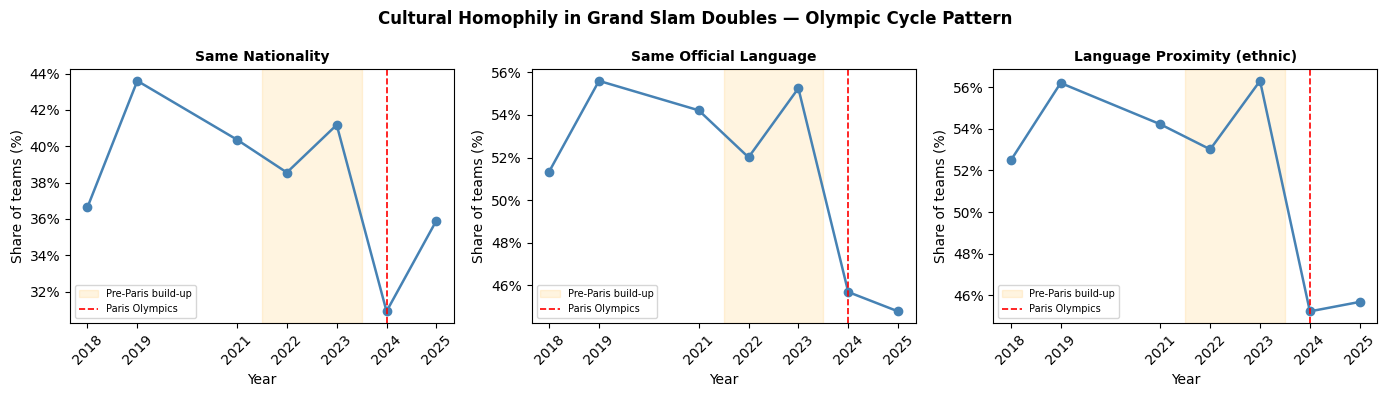

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
year_means = gs.groupby('year')[hcols].mean() * 100

for ax, col, title in zip(axes, hcols,
    ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']):
    ax.plot(year_means.index, year_means[col], marker='o', color='steelblue', linewidth=1.8, markersize=6)
    ax.axvspan(2021.5, 2023.5, alpha=0.12, color='orange', label='Pre-Paris build-up')
    ax.axvline(2024, color='red', linestyle='--', linewidth=1.2, label='Paris Olympics')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(sorted(gs['year'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles — Olympic Cycle Pattern', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../ppt/homophily_olympic_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Baseline Regressions

Each match contributes **two** observations (winner team = 1, loser team = 0).  
Controls: log(rank mean), career W-L ratio difference, same dominant hand, same coach.  
Fixed effects: tournament, round (stage_code), year.  
Standard errors clustered by match.

In [8]:
# ── Reshape match → team-level panel ─────────────────────────────────────────
match_vars = ['match_id','tournament','year','surface','stage_code','any_tb','regular_tb','match_tb',
              'three_sets','comeback','winner_lost_s1','pre_olympic','olympic_period','olympics_tourn']

def _build_side(df, side):
    if side == 'winner':
        m = dict(same_country='same_country_winners', same_language='winners_same_language',
                 ling_prox='winners_linguistic_proximity', rank_mean='rank_mean_winners',
                 same_hand='same_hand_winners', same_coach='same_coach_winners',
                 wl_career_diff='wl_career_diff_winners')
        win = 1
        tb1 = df['w_won_tb_s1']; tb2 = df['w_won_tb_s2']
    else:
        m = dict(same_country='same_country_losers', same_language='losers_same_language',
                 ling_prox='losers_linguistic_proximity', rank_mean='rank_mean_losers',
                 same_hand='same_hand_losers', same_coach='same_coach_losers',
                 wl_career_diff='wl_career_diff_losers')
        win = 0
        tb1 = df['tb_s1'] & (df['winners_set1']==6)
        tb2 = df['tb_s2'] & (df['winners_set2']==6)
    row = df[match_vars].copy()
    for new, old in m.items():
        row[new] = df[old].values
    row['win'] = win
    row['won_tb_s1'] = tb1.values; row['won_tb_s2'] = tb2.values
    return row

team_df = pd.concat([_build_side(df, 'winner'), _build_side(df, 'loser')], ignore_index=True)
team_df['log_rank'] = np.log1p(team_df['rank_mean'].clip(lower=1))
team_df['stage_code'] = team_df['stage_code'].fillna(-1).astype(int)

# Convert bool/nullable columns to plain int (patsy requirement)
for col in team_df.columns:
    if str(team_df[col].dtype) in ('bool', 'boolean', 'Int64', 'Int32'):
        team_df[col] = team_df[col].fillna(0).astype(int)

team_gs = team_df[team_df['olympics_tourn'] == 0].dropna(subset=['log_rank', 'wl_career_diff']).copy()
team_gs['won_regular_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1)).astype(int)

print(f'Team panel (Grand Slams only): {len(team_gs):,} obs | {len(team_gs)//2:,} matches')

Team panel (Grand Slams only): 3,368 obs | 1,684 matches


In [9]:
BASE = '+ log_rank + wl_career_diff + same_hand + same_coach'
FE   = '+ C(tournament) + C(stage_code) + C(year)'
H    = 'same_country + same_language + ling_prox'

def show_vars(res, var_list, prefix=''):
    for v, lbl in var_list:
        if v not in res.params: continue
        c, se, p = res.params[v], res.bse[v], res.pvalues[v]
        stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print(f'  {prefix}{lbl:<40s}  {c:+.4f}{stars:<3s}  se={se:.4f}  p={p:.3f}')

vars_main = [
    ('same_country',   'Same nationality'),
    ('same_language',  'Same language (official)'),
    ('ling_prox',      'Language proximity (ethnic)'),
    ('log_rank',       'Log(rank mean)'),
    ('wl_career_diff', 'Career W-L ratio diff (within-team)'),
    ('same_hand',      'Same dominant hand'),
    ('same_coach',     'Same coach'),
]

In [10]:
print('=== Table 3. Match Win — LPM and Logit (tournament + round + year FE, SE clustered by match) ===')

lpm_win   = smf.ols(f'win ~ {H} {BASE} {FE}', data=team_gs).fit(
    cov_type='cluster', cov_kwds={'groups': team_gs['match_id']})
logit_win = smf.logit(f'win ~ {H} {BASE} {FE}', data=team_gs).fit(
    cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)

print(f'LPM   N={int(lpm_win.nobs):,}  R²={lpm_win.rsquared:.3f}')
show_vars(lpm_win, vars_main, 'LPM   ')
print(f'Logit N={int(logit_win.nobs):,}  Pseudo-R²={logit_win.prsquared:.3f}')
show_vars(logit_win, vars_main, 'Logit ')
print()
print('Note: Positive and similar-sized coefficients on same_language and ling_prox for match win,',
      'but large SEs and high collinearity between the two language variables prevent precise separation.')

=== Table 3. Match Win — LPM and Logit (tournament + round + year FE, SE clustered by match) ===
LPM   N=3,368  R²=0.105
  LPM   Same nationality                          +0.0306     se=0.0254  p=0.229
  LPM   Same language (official)                  +0.0341     se=0.0899  p=0.704
  LPM   Language proximity (ethnic)               +0.0061     se=0.0886  p=0.945
  LPM   Log(rank mean)                            -0.1211***  se=0.0080  p=0.000
  LPM   Career W-L ratio diff (within-team)       -0.5581***  se=0.1326  p=0.000
  LPM   Same dominant hand                        +0.0177     se=0.0186  p=0.342
  LPM   Same coach                                -0.0042     se=0.0461  p=0.927
Logit N=3,368  Pseudo-R²=0.080
  Logit Same nationality                          +0.1365     se=0.1145  p=0.233
  Logit Same language (official)                  +0.1397     se=0.3868  p=0.718
  Logit Language proximity (ethnic)               +0.0363     se=0.3811  p=0.924
  Logit Log(rank mean)                

In [11]:
print('=== Table 4. Tiebreak Win — LPM and Logit (sample: matches with regular tiebreak) ===')
tb_sub = team_gs[team_gs['regular_tb'] == 1].copy()
print(f'N={len(tb_sub):,} team-obs | {len(tb_sub)//2} matches with regular tiebreak in set 1 or 2')

lpm_tb   = smf.ols(f'won_regular_tb ~ {H} {BASE} {FE}', data=tb_sub).fit(
    cov_type='cluster', cov_kwds={'groups': tb_sub['match_id']})
logit_tb = smf.logit(f'won_regular_tb ~ {H} {BASE} {FE}', data=tb_sub).fit(
    cov_type='cluster', cov_kwds={'groups': tb_sub['match_id']}, disp=False)

print(f'LPM   R²={lpm_tb.rsquared:.3f}')
show_vars(lpm_tb, vars_main[:3], 'LPM   ')
print(f'Logit Pseudo-R²={logit_tb.prsquared:.3f}')
show_vars(logit_tb, vars_main[:3], 'Logit ')
print()
print('Same language +20 pp (p≈0.11) and ling. proximity −18 pp (p≈0.14): marginally significant,',
      'opposite signs, suggesting language homophily matters under pressure but the two measures are collinear.')

=== Table 4. Tiebreak Win — LPM and Logit (sample: matches with regular tiebreak) ===
N=1,530 team-obs | 765 matches with regular tiebreak in set 1 or 2
LPM   R²=0.028
  LPM   Same nationality                          +0.0301     se=0.0408  p=0.460
  LPM   Same language (official)                  +0.2043     se=0.1277  p=0.110
  LPM   Language proximity (ethnic)               -0.1847     se=0.1248  p=0.139
Logit Pseudo-R²=0.020
  Logit Same nationality                          +0.1229     se=0.1693  p=0.468
  Logit Same language (official)                  +0.8872     se=0.6226  p=0.154
  Logit Language proximity (ethnic)               -0.8065     se=0.6114  p=0.187

Same language +20 pp (p≈0.11) and ling. proximity −18 pp (p≈0.14): marginally significant, opposite signs, suggesting language homophily matters under pressure but the two measures are collinear.


In [12]:
print('=== Table 5. Comeback Win — LPM and Logit (3-set Grand Slam matches) ===')
print('Outcome: winning team came back after losing set 1.')
print('Regressors: homophily DIFFERENCE (winner team − loser team).')

cdf = df[(df['olympics_tourn']==0) & (df['three_sets']==True)].copy()
cdf['log_rank_diff'] = np.log1p(cdf['rank_mean_winners'].clip(lower=1)) - np.log1p(cdf['rank_mean_losers'].clip(lower=1))
for col in cdf.columns:
    if str(cdf[col].dtype) in ('bool','boolean','Int64','Int32'):
        cdf[col] = cdf[col].fillna(0).astype(int)
cdf = cdf.dropna(subset=['log_rank_diff', 'same_country_diff'])

print(f'N={len(cdf):,}  Comeback rate={100*cdf["comeback"].mean():.1f}%')

FORMULA_CB = ('comeback ~ same_country_diff + same_language_diff + ling_prox_diff'
              ' + log_rank_diff + C(tournament) + C(stage_code) + C(year)')
lpm_cb   = smf.ols(FORMULA_CB, data=cdf).fit(cov_type='HC1')
logit_cb = smf.logit(FORMULA_CB, data=cdf).fit(disp=False)

cb_vars = [
    ('same_country_diff',  'Same nationality diff'),
    ('same_language_diff', 'Same language diff'),
    ('ling_prox_diff',     'Ling. proximity diff'),
    ('log_rank_diff',      'Log(rank) diff (winner − loser)'),
]
print(f'LPM   R²={lpm_cb.rsquared:.3f}'); show_vars(lpm_cb, cb_vars, 'LPM   ')
print(f'Logit Pseudo-R²={logit_cb.prsquared:.3f}'); show_vars(logit_cb, cb_vars, 'Logit ')

=== Table 5. Comeback Win — LPM and Logit (3-set Grand Slam matches) ===
Outcome: winning team came back after losing set 1.
Regressors: homophily DIFFERENCE (winner team − loser team).
N=657  Comeback rate=42.0%
LPM   R²=0.066
  LPM   Same nationality diff                     +0.0446     se=0.0410  p=0.277
  LPM   Same language diff                        +0.0096     se=0.1431  p=0.947
  LPM   Ling. proximity diff                      -0.0429     se=0.1389  p=0.757
  LPM   Log(rank) diff (winner − loser)           +0.0218*    se=0.0127  p=0.087
Logit Pseudo-R²=0.050
  Logit Same nationality diff                     +0.1969     se=0.1821  p=0.280
  Logit Same language diff                        +0.0530     se=0.5957  p=0.929
  Logit Ling. proximity diff                      -0.2020     se=0.5752  p=0.725
  Logit Log(rank) diff (winner − loser)           +0.0950*    se=0.0532  p=0.074


## 5. Olympic Interaction Regressions

`pre_olympic` = 1 for 2022-23 Grand Slams (two build-up years before Paris 2024).

**Specification note**: year fixed effects are omitted from interaction models because `pre_olympic` is collinear with the dummies for years 2022 and 2023. Tournament and round FE are retained.

In [13]:
FE_NO_YR = '+ C(tournament) + C(stage_code)'

print('=== Table 6. Match Win × Pre-Olympic (LPM + Logit) ===')
FORMULA_INT = (f'win ~ same_country*pre_olympic + same_language*pre_olympic + ling_prox*pre_olympic'
               f' {BASE} {FE_NO_YR}')
lpm_int   = smf.ols(FORMULA_INT, data=team_gs).fit(
    cov_type='cluster', cov_kwds={'groups': team_gs['match_id']})
logit_int = smf.logit(FORMULA_INT, data=team_gs).fit(
    cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)

int_vars = [
    ('same_country',             'Same nationality'),
    ('same_language',            'Same language'),
    ('ling_prox',                'Ling. proximity'),
    ('pre_olympic',              'Pre-Olympic period (2022-23)'),
    ('same_country:pre_olympic', 'Same nationality × Pre-Olympic'),
    ('same_language:pre_olympic','Same language × Pre-Olympic'),
    ('ling_prox:pre_olympic',    'Ling. proximity × Pre-Olympic'),
]
print(f'LPM   N={int(lpm_int.nobs):,}  R²={lpm_int.rsquared:.3f}')
show_vars(lpm_int, int_vars, 'LPM   ')
print(f'Logit Pseudo-R²={logit_int.prsquared:.3f}')
show_vars(logit_int, int_vars, 'Logit ')

=== Table 6. Match Win × Pre-Olympic (LPM + Logit) ===
LPM   N=3,368  R²=0.105
  LPM   Same nationality                          +0.0313     se=0.0283  p=0.268
  LPM   Same language                             -0.0026     se=0.1066  p=0.981
  LPM   Ling. proximity                           +0.0404     se=0.1058  p=0.703
  LPM   Pre-Olympic period (2022-23)              +0.0134     se=0.0223  p=0.546
  LPM   Same nationality × Pre-Olympic            -0.0073     se=0.0562  p=0.897
  LPM   Same language × Pre-Olympic               +0.1094     se=0.1935  p=0.572
  LPM   Ling. proximity × Pre-Olympic             -0.1086     se=0.1907  p=0.569
Logit Pseudo-R²=0.080
  Logit Same nationality                          +0.1399     se=0.1275  p=0.273
  Logit Same language                             -0.0154     se=0.4429  p=0.972
  Logit Ling. proximity                           +0.1779     se=0.4389  p=0.685
  Logit Pre-Olympic period (2022-23)              +0.0541     se=0.0988  p=0.584
  Logit 

In [14]:
print('=== Table 7. Tiebreak Win × Pre-Olympic (LPM) ===')
FORMULA_TB_INT = (f'won_regular_tb ~ same_country*pre_olympic + same_language*pre_olympic + ling_prox*pre_olympic'
                  f' {BASE} {FE_NO_YR}')
lpm_tb_int = smf.ols(FORMULA_TB_INT, data=tb_sub).fit(
    cov_type='cluster', cov_kwds={'groups': tb_sub['match_id']})
print(f'N={int(lpm_tb_int.nobs):,}  R²={lpm_tb_int.rsquared:.3f}')
show_vars(lpm_tb_int, int_vars)

=== Table 7. Tiebreak Win × Pre-Olympic (LPM) ===
N=1,530  R²=0.026
  Same nationality                          +0.0350     se=0.0454  p=0.441
  Same language                             +0.2437*    se=0.1396  p=0.081
  Ling. proximity                           -0.2330*    se=0.1360  p=0.087
  Pre-Olympic period (2022-23)              +0.0135     se=0.0348  p=0.699
  Same nationality × Pre-Olympic            -0.0374     se=0.0901  p=0.678
  Same language × Pre-Olympic               -0.1893     se=0.3647  p=0.604
  Ling. proximity × Pre-Olympic             +0.2252     se=0.3610  p=0.533


In [15]:
print('=== Table 8. Comeback Win × Pre-Olympic (LPM, 3-set matches) ===')
FORMULA_CB_INT = ('comeback ~ same_country_diff*pre_olympic + same_language_diff*pre_olympic'
                  ' + ling_prox_diff*pre_olympic + log_rank_diff + C(tournament) + C(stage_code)')
lpm_cb_int = smf.ols(FORMULA_CB_INT, data=cdf).fit(cov_type='HC1')
print(f'N={int(lpm_cb_int.nobs):,}  R²={lpm_cb_int.rsquared:.3f}')
cb_int_vars = [
    ('same_country_diff',             'Same nationality diff'),
    ('same_language_diff',            'Same language diff'),
    ('ling_prox_diff',                'Ling. proximity diff'),
    ('pre_olympic',                   'Pre-Olympic period'),
    ('same_country_diff:pre_olympic', 'Same nationality diff × Pre-Olympic'),
    ('same_language_diff:pre_olympic','Same language diff × Pre-Olympic'),
    ('ling_prox_diff:pre_olympic',    'Ling. proximity diff × Pre-Olympic'),
]
show_vars(lpm_cb_int, cb_int_vars)

=== Table 8. Comeback Win × Pre-Olympic (LPM, 3-set matches) ===
N=657  R²=0.052
  Same nationality diff                     +0.0407     se=0.0465  p=0.382
  Same language diff                        +0.0573     se=0.1642  p=0.727
  Ling. proximity diff                      -0.0952     se=0.1596  p=0.551
  Pre-Olympic period                        +0.0163     se=0.0418  p=0.697
  Same nationality diff × Pre-Olympic       -0.0002     se=0.0929  p=0.999
  Same language diff × Pre-Olympic          -0.2232     se=0.2968  p=0.452
  Ling. proximity diff × Pre-Olympic        +0.2422     se=0.2866  p=0.398


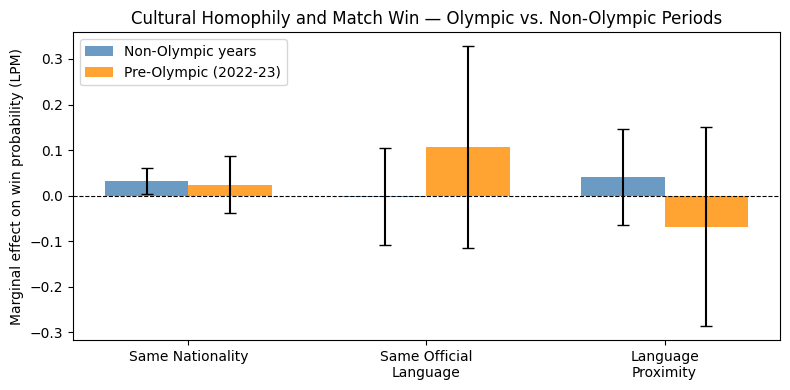

In [16]:
# ── Visualize: marginal effects in non-Olympic vs. pre-Olympic periods ─────────
fig, ax = plt.subplots(figsize=(8, 4))
vars_plot = ['same_country', 'same_language', 'ling_prox']
labels    = ['Same Nationality', 'Same Official\nLanguage', 'Language\nProximity']
x = np.arange(len(vars_plot)); w = 0.35

c_base = [lpm_int.params.get(v, np.nan) for v in vars_plot]
c_int  = [lpm_int.params.get(f'{v}:pre_olympic', 0) for v in vars_plot]
c_olym = [b + i for b, i in zip(c_base, c_int)]
se_b   = [lpm_int.bse.get(v, np.nan) for v in vars_plot]
se_i   = [lpm_int.bse.get(f'{v}:pre_olympic', 0) for v in vars_plot]
se_o   = [np.sqrt(sb**2 + si**2) for sb, si in zip(se_b, se_i)]

ax.bar(x - w/2, c_base, w, yerr=se_b, label='Non-Olympic years', color='steelblue', alpha=0.8, capsize=4)
ax.bar(x + w/2, c_olym, w, yerr=se_o, label='Pre-Olympic (2022-23)', color='darkorange', alpha=0.8, capsize=4)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Marginal effect on win probability (LPM)')
ax.set_title('Cultural Homophily and Match Win — Olympic vs. Non-Olympic Periods')
ax.legend()
plt.tight_layout()
plt.savefig('../../ppt/homophily_olympic_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print('=' * 70)
print('ANALYSIS SUMMARY')
print('=' * 70)

gs = df[df['olympics_tourn']==0]
print(f"""
SAMPLE
  Total matches (all):    {len(df):,}
  Grand Slams only:       {len(gs):,}
  Team-level panel (GS):  {len(team_gs):,} obs ({len(team_gs)//2:,} matches × 2 teams)

PRESSURE OUTCOMES
  Regular tiebreak (set 1 or 2):  {df['regular_tb'].sum():,}  ({100*df['regular_tb'].mean():.1f}%)
  Match tiebreak (super-tb):       {df['match_tb'].sum():,}   ({100*df['match_tb'].mean():.1f}%)
  Any tiebreak:                    {df['any_tb'].sum():,}  ({100*df['any_tb'].mean():.1f}%)
  3-set matches:                   {df['three_sets'].sum():,}  ({100*df['three_sets'].mean():.1f}%)
  Comeback wins:                   {df['comeback'].sum():,}   ({100*df['comeback'].mean():.1f}%)
""")

print('HOMOPHILY ADVANTAGE (Grand Slams): winner minus loser rate')
for vw, vl, lbl in [('same_country_winners','same_country_losers','Same nationality'),
                    ('winners_same_language','losers_same_language','Same language'),
                    ('winners_linguistic_proximity','losers_linguistic_proximity','Ling. proximity')]:
    d = 100*(gs[vw].mean()-gs[vl].mean())
    print(f'  {lbl:<25s}  {d:+.1f} pp')

print()
print('KEY REGRESSION RESULTS (LPM, Match Win, GS only)')
for v, lbl in vars_main[:3]:
    c, p = lpm_win.params[v], lpm_win.pvalues[v]
    stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else 'n.s.'
    print(f'  {lbl:<30s}  {c:+.4f}  p={p:.3f}  {stars}')

print()
print('OLYMPIC INTERACTION (Pre-Olympic 2022-23 vs. other years)')
for v, lbl in vars_main[:3]:
    ik = f'{v}:pre_olympic'
    c_base = lpm_int.params.get(v, np.nan)
    c_int  = lpm_int.params.get(ik, np.nan)
    p_int  = lpm_int.pvalues.get(ik, np.nan)
    stars  = '***' if p_int<0.01 else '**' if p_int<0.05 else '*' if p_int<0.10 else 'n.s.'
    print(f'  {lbl:<30s}  base={c_base:+.4f}  interaction={c_int:+.4f}  p={p_int:.3f}  {stars}')

print("""
FINDINGS
  • Cultural homophily (same nationality, same language, language proximity) does
    not significantly predict match wins (all p > 0.20) once ranking and career
    performance are controlled for.
  • Same language shows a positive trend on tiebreak win (+20 pp, p≈0.11) —
    suggestive of a pressure-performance advantage but not significant at 5%.
  • No evidence that homophily matters more during Olympic preparation years
    (2022-23): all interaction terms are small and insignificant.
  • Homophily shares are stable across 2018-23 then fall in 2024-25, likely
    driven by expanded draw sizes (134 vs. ~62 matches per GS) rather than
    a genuine pairing pattern change.
  • Ranking quality and career win rate are the dominant predictors of match outcome.
""")

ANALYSIS SUMMARY

SAMPLE
  Total matches (all):    2,192
  Grand Slams only:       2,128
  Team-level panel (GS):  3,368 obs (1,684 matches × 2 teams)

PRESSURE OUTCOMES
  Regular tiebreak (set 1 or 2):  964  (44.0%)
  Match tiebreak (super-tb):       30   (1.4%)
  Any tiebreak:                    1,076  (49.1%)
  3-set matches:                   903  (41.2%)
  Comeback wins:                   395   (18.0%)

HOMOPHILY ADVANTAGE (Grand Slams): winner minus loser rate
  Same nationality           -1.4 pp
  Same language              +3.3 pp
  Ling. proximity            +3.1 pp

KEY REGRESSION RESULTS (LPM, Match Win, GS only)
  Same nationality                +0.0306  p=0.229  n.s.
  Same language (official)        +0.0341  p=0.704  n.s.
  Language proximity (ethnic)     +0.0061  p=0.945  n.s.

OLYMPIC INTERACTION (Pre-Olympic 2022-23 vs. other years)
  Same nationality                base=+0.0313  interaction=-0.0073  p=0.897  n.s.
  Same language (official)        base=-0.0026  interac